In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import seaborn as sns

## Fuentes
- https://www.geeksforgeeks.org/deep-learning/multi-layer-perceptron-learning-in-tensorflow/
- https://www.geeksforgeeks.org/machine-learning/activation-functions-neural-networks/

## Carga de datos
Los datos fueron preprocesados en Ciencia de Datos: se eliminaron valores atípicos, se seleccionaron variables relevantes y se aplicó estandarización (Z-score).

Se cargan los conjuntos de entrenamiento y test ya preparados.

In [33]:
train = pd.read_csv("./data/train.csv")
test = pd.read_csv("./data/test.csv")

In [34]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nDistribución del target en train:\n{train['target'].value_counts()}")
print(f"\nDistribución del target en test:\n{test['target'].value_counts()}")
train.describe()

Train shape: (11616, 6)
Test shape: (2905, 6)

Distribución del target en train:
target
1    5985
0    5631
Name: count, dtype: int64

Distribución del target en test:
target
1    1497
0    1408
Name: count, dtype: int64


,product_type,air_temp [K],process_temp [K],torque [Nm],tool_wear [min],target
count,11616.000000,1.161600e+04,1.161600e+04,1.161600e+04,1.161600e+04,11616.000000
mean,0.387138,-4.465360e-15,-9.512440e-15,-1.761676e-16,-2.355019e-17,0.515238
std,0.663937,1.000043e+00,1.000043e+00,1.000043e+00,1.000043e+00,0.499789
min,0.000000,-2.671222e+00,-3.376150e+00,-2.896833e+00,-1.789705e+00,0.000000
25%,0.000000,-8.156179e-01,-7.301602e-01,-6.318700e-01,-8.622280e-01,0.000000
50%,0.000000,6.063967e-02,1.392366e-01,1.264018e-01,5.098029e-02,1.000000
75%,1.000000,8.853527e-01,6.911146e-01,7.041662e-01,9.641886e-01,1.000000
max,2.000000,2.070878e+00,2.747427e+00,2.218599e+00,1.820321e+00,1.000000


In [35]:
train

,product_type,air_temp [K],process_temp [K],torque [Nm],tool_wear [min],target
0,0.0,-1.588786,-1.334958,0.509232,-1.090530,0
1,1.0,-1.485697,-1.108159,0.692203,0.307820,0
2,0.0,-1.207357,-1.478597,1.317821,-1.518596,1
3,0.0,0.452378,0.675995,0.240406,1.221028,1
4,0.0,-1.073341,-0.654560,-0.131164,0.578929,0
...,...,...,...,...,...,...
11611,0.0,0.864735,0.751594,0.849135,1.178222,1
11612,0.0,0.472996,0.328236,-0.074866,1.206760,0
11613,0.0,0.163729,1.386632,-0.539329,0.550391,0
11614,0.0,0.730719,0.456755,1.384676,-1.033455,1


In [36]:
test

,product_type,air_temp [K],process_temp [K],torque [Nm],tool_wear [min],target
0,0.0,-0.970252,-0.276562,0.051806,0.265013,0
1,0.0,-0.599131,-0.669680,-0.219835,1.178222,1
2,2.0,1.658521,2.067030,0.340336,-1.761167,0
3,1.0,0.936897,-0.049763,-0.504143,-1.347370,0
4,0.0,1.658521,1.613431,0.086993,-0.391355,0
...,...,...,...,...,...,...
2900,0.0,-0.325945,0.063637,1.305858,-0.519775,1
2901,2.0,-0.609440,-1.032559,0.030694,0.935651,0
2902,0.0,-0.836236,-0.397521,-1.215616,0.479047,1
2903,0.0,-0.037295,0.184596,-2.435185,0.093787,1


## Actividades

Separación de features (X) y target (y) para ambos conjuntos

In [37]:
X_train = train.drop('target', axis=1)
y_train = train['target']
X_test = test.drop(columns=['target'])
y_test = test['target']

print(f"Features de entrada: {X_train.shape[1]} ({list(X_train.columns)})")

Features de entrada: 5 (['product_type', 'air_temp [K]', 'process_temp [K]', 'torque [Nm]', 'tool_wear [min]'])


### Actividad 1

#### Decisiones de diseño

Input(5) → Dense(32, relu) → Dropout → Dense(32, relu) → Dropout → Dense(1, sigmoid).

**Arquitectura MLP (capas ocultas → 1 neurona de salida):**
- Se utiliza un patrón "embudo" (neuronas decrecientes) que fuerza a la
  red a comprimir progresivamente la representación de los datos.
- Con solo 5 features de entrada, una red de 2 capas ocultas es suficiente
  para capturar relaciones no lineales sin sobreajustar.

**Funciones de activación:**
- **ReLU** en capas ocultas: es el estándar porque evita el problema
  de "vanishing gradient" y es computacionalmente eficiente.
- **Sigmoid** en la capa de salida: mapea la salida al rango [0, 1],
  interpretable como la probabilidad de falla (clase positiva).
  Se usa sigmoid (y no softmax) porque tenemos 1 sola neurona de salida
  para clasificación binaria. Softmax se emplea cuando hay 2+ neuronas de
  salida (clasificación multiclase), ya que normaliza un vector para que
  las probabilidades sumen 1.

**Regularización (Dropout):**
- Durante el entrenamiento, se "apagan" aleatoriamente un porcentaje de las
  neuronas en cada paso. Esto evita co-adaptación y reduce el sobreajuste.

**Loss binary_crossentropy:**
- Es la función de pérdida estándar para clasificación binaria.
  Mide la divergencia entre la distribución predicha y la real.

La cantidad exacta de neuronas, la tasa de dropout, el learning rate, el
batch size y el optimizador serán determinados mediante búsqueda
automatizada de hiperparámetros (Actividad 2).

## Actividad 2: Ajuste de hiperparámetros con Keras Tuner

Para encontrar la mejor combinación de hiperparámetros se utiliza
**Keras Tuner**, una librería que automatiza la búsqueda de hiperparámetros
óptimos. En lugar de probar manualmente cada combinación (lo cual sería
impráctico dado el número de posibilidades), Keras Tuner:

1. Define un **espacio de búsqueda** con los rangos de cada hiperparámetro
2. Ejecuta múltiples **trials** (entrenamientos con distintas combinaciones)
3. Rankea los resultados según una métrica objetivo (en nuestro caso,
   `val_accuracy`)
4. Devuelve la mejor configuración encontrada

Se utiliza `RandomSearch` como estrategia de búsqueda, que muestrea
combinaciones aleatorias del espacio. Esto es más eficiente que un grid
search exhaustivo cuando el espacio es grande.

### Hiperparámetros explorados

| Hiperparámetro | Valores explorados |
|---|---|
| Neuronas capa 1 | 32, 64, 128 |
| Neuronas capa 2 | 16, 32, 64 |
| Tasa de aprendizaje | 0.01, 0.001, 0.0001 |
| Dropout | 0.0, 0.2, 0.3, 0.5 |
| Regularización L2 | 0.0, 0.001, 0.01 |
| Optimizador | Adam, SGD (momentum=0.9), RMSprop |


### MEJORAS POSIBLES:
> - Se podría cambiar la estrategia de búsqueda por Hyperband o BayesianOptimization
> - Se podrían expandir los hiperparámetros (probar con otros valores o generar más)
> - Se podría cambiar la cantidad de capas ocultas (probar con 1 o 3)

In [38]:
def build_model(hp):
    """
    Función que construye un modelo MLP parametrizado.
    Keras Tuner invoca esta función en cada trial, variando los
    hiperparámetros definidos con hp.Choice().
    """
    units_1 = hp.Choice('units_1', [32, 64, 128])
    units_2 = hp.Choice('units_2', [16, 32, 64])

    dropout_rate = hp.Choice('dropout', [0.0, 0.2, 0.3, 0.5])
    l2_value = hp.Choice('l2_reg', [0.0, 0.001, 0.01])

    lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    opt_name = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])

    regularizer = keras.regularizers.l2(l2_value) if l2_value > 0 else None

    model = keras.Sequential([
        keras.layers.Input(shape=(X_train.shape[1],)),
        keras.layers.Dense(units_1, activation='relu',
                           kernel_regularizer=regularizer),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(units_2, activation='relu',
                           kernel_regularizer=regularizer),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    if opt_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

### Ejecución de la búsqueda
Se configuran 50 trials  y se entrena cada uno por hasta 50 épocas con EarlyStopping (patience=10) para ahorrar tiempo cuando el modelo deja de mejorar.

> - Se podría probar con más trials ya que la cantidad de combinaciones 972 (por los hiperparámetros)

In [39]:
import shutil
if os.path.exists('tuner_results'):
    shutil.rmtree('tuner_results')

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=50,
    executions_per_trial=1,
    directory='tuner_results',
    project_name='tp_ia',
    seed=42
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# tuner.search(
#     X_train, y_train,
#     epochs=50,
#     batch_size=32,
#     validation_data=(X_test, y_test), --> esto usa  el test set como validation set (data LEAKAGE)
#     callbacks=[early_stop],
#     verbose=1
# )

tuner.search(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20, # --> esto divide el training set para validation set (quizás seria mejor tenerlo desde el TP de CDD)
    callbacks=[early_stop],
    verbose=1
)

Trial 50 Complete [00h 00m 15s]
val_accuracy: 0.903184175491333

Best val_accuracy So Far: 0.9444922804832458
Total elapsed time: 00h 20m 15s


### Resultados de la búsqueda
Se muestran los mejores hiperparámetros encontrados y un resumen de todos los trials ejecutados.

In [40]:
tuner.results_summary(num_trials=5)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n" + "="*60)
print("MEJOR CONFIGURACIÓN ENCONTRADA:")
print(f"  Neuronas capa 1:   {best_hp.get('units_1')}")
print(f"  Neuronas capa 2:   {best_hp.get('units_2')}")
print(f"  Dropout:           {best_hp.get('dropout')}")
print(f"  Regularización L2: {best_hp.get('l2_reg')}")
print(f"  Learning Rate:     {best_hp.get('learning_rate')}")
print(f"  Optimizador:       {best_hp.get('optimizer')}")
print("="*60)

Results summary
Results in tuner_results/tp_ia
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 17 summary
Hyperparameters:
units_1: 32
units_2: 32
dropout: 0.0
l2_reg: 0.0
learning_rate: 0.01
optimizer: adam
Score: 0.9444922804832458

Trial 25 summary
Hyperparameters:
units_1: 64
units_2: 32
dropout: 0.2
l2_reg: 0.0
learning_rate: 0.001
optimizer: adam
Score: 0.9427710771560669

Trial 31 summary
Hyperparameters:
units_1: 128
units_2: 32
dropout: 0.2
l2_reg: 0.0
learning_rate: 0.001
optimizer: adam
Score: 0.9427710771560669

Trial 40 summary
Hyperparameters:
units_1: 64
units_2: 32
dropout: 0.0
l2_reg: 0.0
learning_rate: 0.001
optimizer: rmsprop
Score: 0.9423407912254333

Trial 14 summary
Hyperparameters:
units_1: 64
units_2: 64
dropout: 0.0
l2_reg: 0.001
learning_rate: 0.001
optimizer: adam
Score: 0.9419105052947998

MEJOR CONFIGURACIÓN ENCONTRADA:
  Neuronas capa 1:   32
  Neuronas capa 2:   32
  Dropout:           0.0
  Regularización L2: 0.0
  Learning R

### Exploración del efecto del batch size
Keras Tuner no varía el batch_size directamente (se pasa a .search()), así que lo exploramos manualmente con la mejor configuración encontrada.

In [41]:
resultados_batch = []
batch_sizes = [16, 32, 64, 128]

for bs in batch_sizes:
    print(f"\n--- Batch Size: {bs} ---")
    model = tuner.hypermodel.build(best_hp)
    es = EarlyStopping(monitor='val_loss', patience=10,
                       restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=50, batch_size=bs,
                        validation_data=(X_test, y_test),
                        callbacks=[es], verbose=0)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"  val_loss={loss:.4f}, val_accuracy={acc:.4f}")
    resultados_batch.append({
        'batch_size': bs,
        'val_loss': round(loss, 4),
        'val_accuracy': round(acc, 4),
        'epocas': len(history.history['loss'])
    })

df_batch = pd.DataFrame(resultados_batch)
print("\n=== Comparación de batch sizes ===")
print(df_batch.sort_values('val_accuracy', ascending=False).to_string(index=False))

# Entre los que tienen el mejor val_accuracy, elegir el mayor batch size (más eficiente) porque ocupa menos épocas
max_acc = df_batch['val_accuracy'].max()
mejor_batch = df_batch.loc[df_batch['val_accuracy'] == max_acc, 'batch_size'].max()
print(f"\nMejor batch size: {mejor_batch}")


--- Batch Size: 16 ---
  val_loss=0.1387, val_accuracy=0.9477

--- Batch Size: 32 ---
  val_loss=0.1371, val_accuracy=0.9497

--- Batch Size: 64 ---
  val_loss=0.1549, val_accuracy=0.9408

--- Batch Size: 128 ---
  val_loss=0.1462, val_accuracy=0.9435

=== Comparación de batch sizes ===
 batch_size  val_loss  val_accuracy  epocas
         32    0.1371        0.9497      43
         16    0.1387        0.9477      50
        128    0.1462        0.9435      50
         64    0.1549        0.9408      36

Mejor batch size: 32


### Entrenamiento del modelo final
Se construye y entrena el modelo con la configuración óptima encontrada (mejores hiperparámetros de Keras Tuner + mejor batch size).
Se aumentan las épocas máximas a 100 y el patience a 15 para permitir una convergencia más completa.

In [42]:
modelo_final = tuner.hypermodel.build(best_hp)
modelo_final.summary()

early_stop_final = EarlyStopping(monitor='val_loss', patience=15,
                                  restore_best_weights=True)

history_final = modelo_final.fit(
    X_train, y_train,
    epochs=100,
    batch_size=int(mejor_batch),
    validation_data=(X_test, y_test),
    callbacks=[early_stop_final],
    verbose=1
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8844 - loss: 0.2820 - val_accuracy: 0.9074 - val_loss: 0.2313
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9192 - loss: 0.2102 - val_accuracy: 0.9153 - val_loss: 0.2193
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9221 - loss: 0.1983 - val_accuracy: 0.9253 - val_loss: 0.2061
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9242 - loss: 0.1929 - val_accuracy: 0.9205 - val_loss: 0.1928
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9274 - loss: 0.1827 - val_accuracy: 0.9287 - val_loss: 0.1911
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9320 - loss: 0.1772 - val_accuracy: 0.9256 - val_loss: 0.1965
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9320 - loss: 0.1751 - val_accuracy: 0.9212 - val_loss: 0.1867
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9332 - loss: 0.1718 - val_accu

## Actividad 3: Evaluación del modelo

### Curvas de aprendizaje
Se grafican las curvas de loss y accuracy para entrenamiento y validación.
Estas curvas permiten detectar:
- **Overfitting**: val_loss sube mientras train_loss baja
- **Underfitting**: ambas curvas se estancan en valores altos
- **Buen ajuste**: ambas curvas convergen en valores bajos y similares

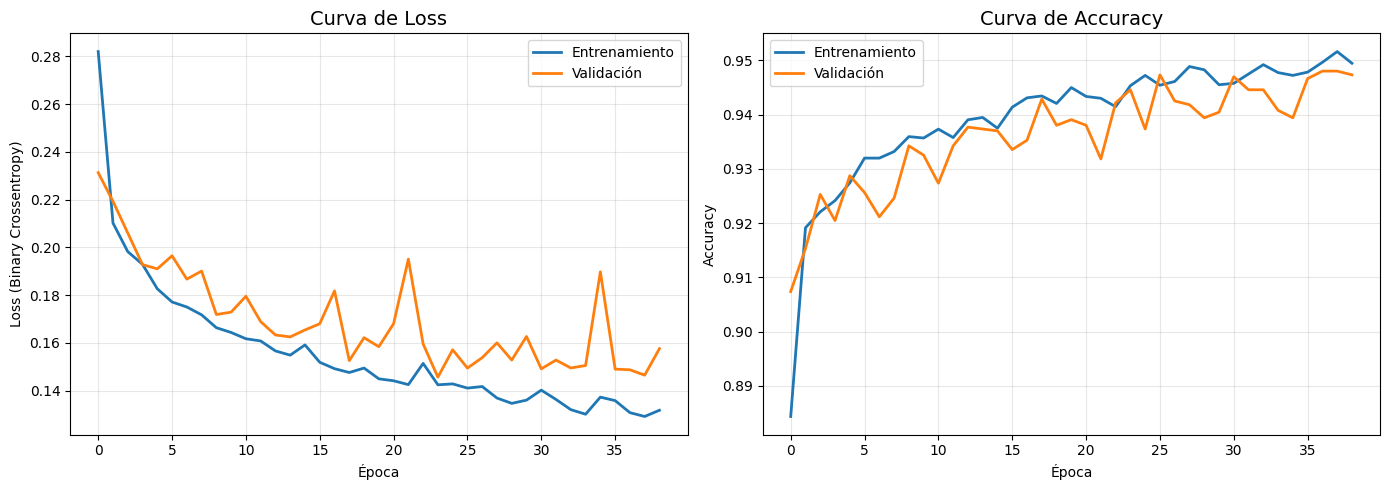

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_final.history['loss'], label='Entrenamiento', linewidth=2)
ax1.plot(history_final.history['val_loss'], label='Validación', linewidth=2)
ax1.set_title('Curva de Loss', fontsize=14)
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss (Binary Crossentropy)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_final.history['accuracy'], label='Entrenamiento', linewidth=2)
ax2.plot(history_final.history['val_accuracy'], label='Validación', linewidth=2)
ax2.set_title('Curva de Accuracy', fontsize=14)
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

Se puede apreciar que la generalización sobre datos no vistos (los de validación) es más inestable.
Esto se puede asociar a ruido o pocos datos de entrenamiento/validación.

### Métricas de clasificación
Se calculan métricas estándar para clasificación binaria:
- **Accuracy**: proporción de predicciones correctas
- **Precision**: de los predichos positivos, cuántos son realmente positivos
- **Recall**: de los realmente positivos, cuántos fueron detectados
- **F1-Score**: media armónica de precision y recall
- **AUC-ROC**: capacidad del modelo para distinguir entre clases

In [44]:
y_pred_proba = modelo_final.predict(X_test).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

print("=== Reporte de Clasificación ===\n")
print(classification_report(y_test, y_pred,
                            target_names=['No falla (0)', 'Falla (1)']))

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc_score:.4f}")

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
=== Reporte de Clasificación ===

              precision    recall  f1-score   support

No falla (0)       0.96      0.93      0.94      1408
   Falla (1)       0.93      0.96      0.95      1497

    accuracy                           0.94      2905
   macro avg       0.95      0.94      0.94      2905
weighted avg       0.94      0.94      0.94      2905

AUC-ROC: 0.9849


### Matriz de confusión
Muestra la distribución de predicciones correctas e incorrectas.
Permite identificar si el modelo falla más en falsos positivos (predice falla cuando no la hay) o falsos negativos (no detecta fallas reales).

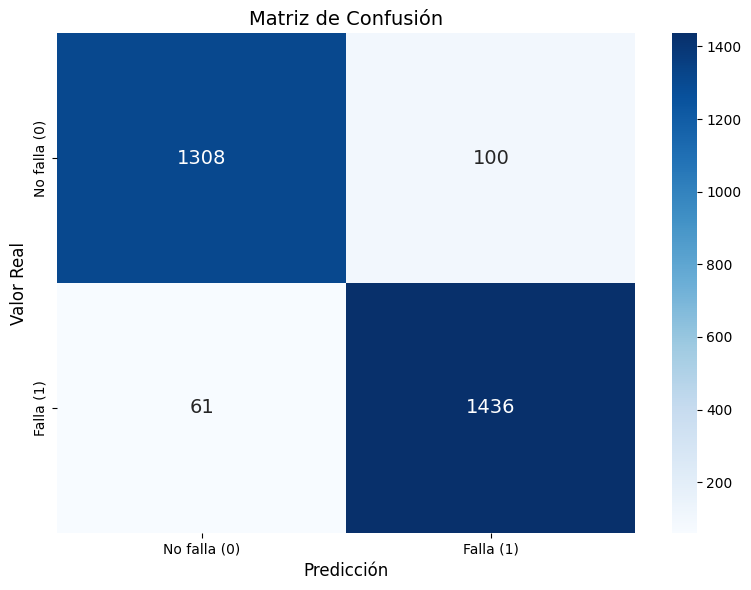

In [45]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No falla (0)', 'Falla (1)'],
            yticklabels=['No falla (0)', 'Falla (1)'],
            ax=ax, annot_kws={"size": 14})
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Valor Real', fontsize=12)
ax.set_title('Matriz de Confusión', fontsize=14)
plt.tight_layout()
# plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### Curva ROC
La curva ROC grafica la tasa de verdaderos positivos (TPR) vs. la tasa de falsos positivos (FPR) para distintos umbrales de decisión. Un AUC cercano a 1.0 indica excelente capacidad discriminativa.

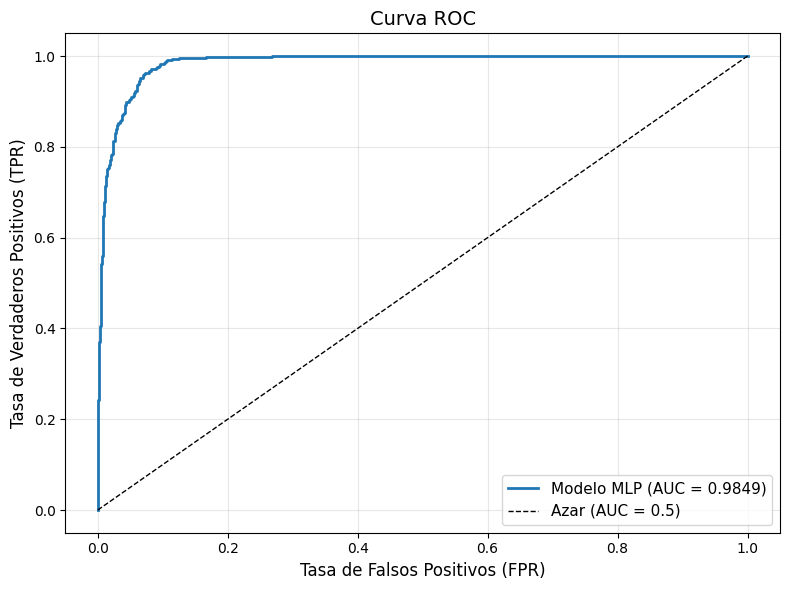

In [46]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, linewidth=2, label=f'Modelo MLP (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Azar (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()